# Las plantas absorben menos CO₂ desde 2001 — y son las tierras secas las culpables

**40 años de datos satelitales** lo dejan en evidencia: la absorción de carbono vegetal global se está frenando, y el frenado se concentra en las tierras secas. En las regiones húmedas, la planta sigue tragando CO₂ casi al mismo ritmo. ¿Qué cambió?

**Paper:** Li et al. (2026) — *Dryland dominance in the slowdown of global vegetation carbon uptake*
**DOI:** [10.1038/s41561-026-01957-8](https://doi.org/10.1038/s41561-026-01957-8) · *Nature Geoscience*

[![Abrir en Colab](https://colab.research.google.com/assets/colab-badge.svg)](https://colab.research.google.com/github/Ciencia-a-Mordiscos/lab/blob/main/papers/2026-04-01-tierras-secas-frenan-co2-vegetal/notebook.ipynb)

> **Video:** [Pendiente]

## Lo que veremos

Cada año, las plantas del planeta absorben CO₂ del aire vía fotosíntesis. A esa absorción bruta se le llama GPP (*gross primary production*) y se mide en **gramos de carbono por metro cuadrado por año**. Es uno de los frenos naturales del cambio climático: cuanto más absorbe la vegetación, menos CO₂ queda en la atmósfera.

Li y su equipo cruzaron datos de **FLUXNET** (torres que miden flujos de carbono *in situ*) con *machine learning* para reconstruir el GPP global de **1982 a 2022**, dividiéndolo en dos zonas:

- **Tierras secas** (drylands): índice de aridez < 0.65 — sabanas, estepas, bordes de desierto.
- **Regiones húmedas** (humid): bosques tropicales, templados, taiga.

La pregunta que abrieron: ¿siguen absorbiendo CO₂ al mismo ritmo que antes? Vamos a los datos.

In [1]:
# ══════════════════════════════════════════════════════════════
# Configuración — modifica estos valores para explorar
# ══════════════════════════════════════════════════════════════
ANIO_QUIEBRE = 2001               # Año en que el paper detecta cambio de tendencia
COLOR_DRYLANDS = '#D97706'        # Amber — tierras secas
COLOR_HUMID = '#059669'           # Emerald — regiones húmedas
COLOR_VPD = '#DC2626'             # Rojo — sospechoso climático
COLOR_DGVM = '#7C3AED'            # Violeta — modelos vegetación
COLOR_ESM = '#2563EB'             # Azul CaM — modelos del clima
FUENTE = 'Fuente: Li et al. (2026), Nature Geoscience | Datos: Zenodo 18476284'
# ══════════════════════════════════════════════════════════════

import os, urllib.request
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from scipy import stats

# Cargar estilo CaM
style_file = '../../cam.mplstyle'
if not os.path.exists(style_file):
    style_file = '/tmp/cam.mplstyle'
    if not os.path.exists(style_file):
        urllib.request.urlretrieve(
            'https://raw.githubusercontent.com/Ciencia-a-Mordiscos/lab/main/cam.mplstyle',
            style_file)
plt.style.use(style_file)

# Carga de datos
serie = pd.read_csv('datos/serie_anual_clima_gpp.csv')
trend_aridez = pd.read_csv('datos/tendencia_gpp_por_aridez.csv')
obs_dgvm = pd.read_csv('datos/observacion_vs_dgvm_por_aridez.csv')
obs_esm = pd.read_csv('datos/observacion_vs_esm_por_aridez.csv')

print(f"Serie temporal: {len(serie)} años ({serie['anio'].min()}–{serie['anio'].max()})")
print(f"Tendencia por aridez: {len(trend_aridez)} bins (índice {trend_aridez['indice_aridez'].min():.2f}–{trend_aridez['indice_aridez'].max():.2f})")
print(f"ML vs DGVMs: {len(obs_dgvm)} bins | ML vs ESMs: {len(obs_esm)} bins")
print(f"\nCO₂ 1982: {serie['co2_ppm'].iloc[0]:.1f} ppm  →  CO₂ 2022: {serie['co2_ppm'].iloc[-1]:.1f} ppm")

Serie temporal: 41 años (1982–2022)
Tendencia por aridez: 39 bins (índice 0.15–3.95)
ML vs DGVMs: 100 bins | ML vs ESMs: 100 bins

CO₂ 1982: 340.9 ppm  →  CO₂ 2022: 417.1 ppm


## Aquí está.

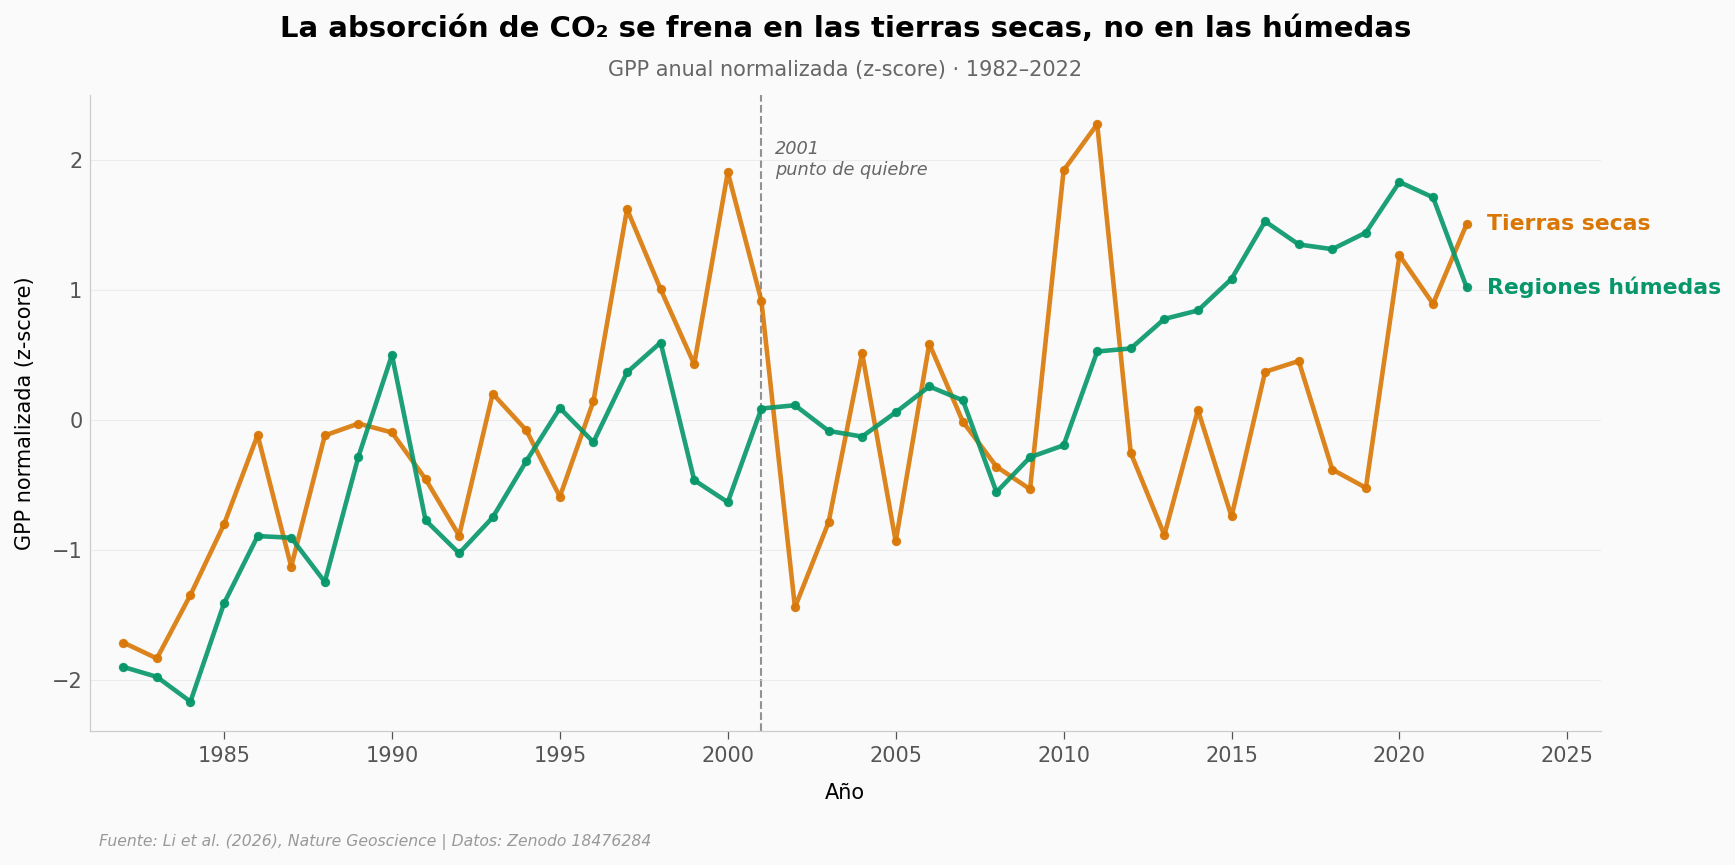


Tendencias (gC/m²/año por año, ± SE de regresión lineal):
  Tierras secas  1982–2000: +2.73  (p=8.6e-06) — significativa
  Tierras secas  2001–2022: +0.77  (p=0.21) — NO significativa
  Regiones húmedas 1982–2000: +2.85  (p=2.1e-04) — significativa
  Regiones húmedas 2001–2022: +2.49  (p=4.1e-07) — significativa

Cambio relativo del slope post-2001:
  Tierras secas:  -71.7%  (cayó a 0.28× la tendencia previa)
  Regiones húmedas: -12.6%  (se mantuvo a 0.87× la tendencia previa)


In [2]:
# Calcular slopes pre/post 2001 para drylands y humid
def slope_period(df, col, t0, t1):
    sub = df[(df['anio'] >= t0) & (df['anio'] <= t1)]
    res = stats.linregress(sub['anio'], sub[col])
    return res.slope, res.pvalue

slope_dry_pre,  p_dry_pre  = slope_period(serie, 'gpp_drylands_gC_m2_yr', 1982, 2000)
slope_dry_post, p_dry_post = slope_period(serie, 'gpp_drylands_gC_m2_yr', 2001, 2022)
slope_hum_pre,  p_hum_pre  = slope_period(serie, 'gpp_humid_gC_m2_yr', 1982, 2000)
slope_hum_post, p_hum_post = slope_period(serie, 'gpp_humid_gC_m2_yr', 2001, 2022)

fig, ax = plt.subplots(figsize=(13, 5.5))

# Series anuales (z-score normalizado para comparar evolución)
def zscore(x):
    return (x - x.mean()) / x.std()

ax.plot(serie['anio'], zscore(serie['gpp_drylands_gC_m2_yr']),
        color=COLOR_DRYLANDS, linewidth=2.2, marker='o', markersize=3.5, alpha=0.9)
ax.plot(serie['anio'], zscore(serie['gpp_humid_gC_m2_yr']),
        color=COLOR_HUMID, linewidth=2.2, marker='o', markersize=3.5, alpha=0.9)

# Línea vertical en el año de quiebre
ax.axvline(x=ANIO_QUIEBRE, color='#666666', linewidth=1.0, linestyle='--', alpha=0.7, zorder=1)
ax.text(ANIO_QUIEBRE + 0.4, 2.15, f'2001\npunto de quiebre',
        fontsize=8.5, color='#666666', ha='left', va='top', style='italic')

# Etiquetas inline (final de las series)
ax.text(2022.6, zscore(serie['gpp_drylands_gC_m2_yr']).iloc[-1],
        'Tierras secas', fontsize=10.5, color=COLOR_DRYLANDS, fontweight='bold', va='center')
ax.text(2022.6, zscore(serie['gpp_humid_gC_m2_yr']).iloc[-1],
        'Regiones húmedas', fontsize=10.5, color=COLOR_HUMID, fontweight='bold', va='center')

ax.set_title('La absorción de CO₂ se frena en las tierras secas, no en las húmedas',
             fontsize=14, fontweight='bold', pad=28)
ax.text(0.5, 1.03, 'GPP anual normalizada (z-score) · 1982–2022',
        transform=ax.transAxes, fontsize=10, color='#666666', ha='center')
ax.set_xlabel('Año', fontsize=10)
ax.set_ylabel('GPP normalizada (z-score)', fontsize=10)
ax.set_xlim(1981, 2026)

fig.text(0.13, -0.03, FUENTE, fontsize=7.5, color='#999999', style='italic')
plt.savefig('figuras/01_gpp_drylands_vs_humid.png', dpi=200, bbox_inches='tight')
plt.show()

# Reportar slopes
print("\nTendencias (gC/m²/año por año, ± SE de regresión lineal):")
print(f"  Tierras secas  1982–2000: {slope_dry_pre:+.2f}  (p={p_dry_pre:.1e}) — significativa")
print(f"  Tierras secas  2001–2022: {slope_dry_post:+.2f}  (p={p_dry_post:.2f}) — NO significativa")
print(f"  Regiones húmedas 1982–2000: {slope_hum_pre:+.2f}  (p={p_hum_pre:.1e}) — significativa")
print(f"  Regiones húmedas 2001–2022: {slope_hum_post:+.2f}  (p={p_hum_post:.1e}) — significativa")
print(f"\nCambio relativo del slope post-2001:")
print(f"  Tierras secas:  {(slope_dry_post / slope_dry_pre - 1) * 100:+.1f}%  (cayó a {slope_dry_post/slope_dry_pre:.2f}× la tendencia previa)")
print(f"  Regiones húmedas: {(slope_hum_post / slope_hum_pre - 1) * 100:+.1f}%  (se mantuvo a {slope_hum_post/slope_hum_pre:.2f}× la tendencia previa)")

## Lo que llama la atención

Hasta el año 2000, las dos zonas suben casi al mismo ritmo. Después, las trayectorias se separan: las tierras secas se aplanan mientras las húmedas siguen subiendo.

Los números lo confirman. En las tierras secas el ritmo de absorción cayó de **+2.7 a +0.8 gC/m²/año por año** — una reducción del **72%**, y el segundo slope ya ni siquiera es estadísticamente significativo (p=0.21). En las húmedas, el slope solo bajó **13%** (de +2.8 a +2.5) y sigue siendo robusto (p=4×10⁻⁷).

Es la asimetría que el paper se propuso explicar. Si la fertilización por CO₂ explicara todo el GPP, esperaríamos ver subidas paralelas — más CO₂ disponible = más fotosíntesis, en cualquier zona. Pero en las tierras secas algo está bloqueando ese impulso. ¿Qué?

## El sospechoso climático: VPD

VPD = *vapour pressure deficit*. Es la "sed" del aire — cuánto le falta al aire para saturarse de humedad. Cuando sube, las plantas cierran sus estomas para no perder agua, y al cerrarlos también dejan de absorber CO₂.

Veamos qué hizo el VPD en las tierras secas durante el mismo período.

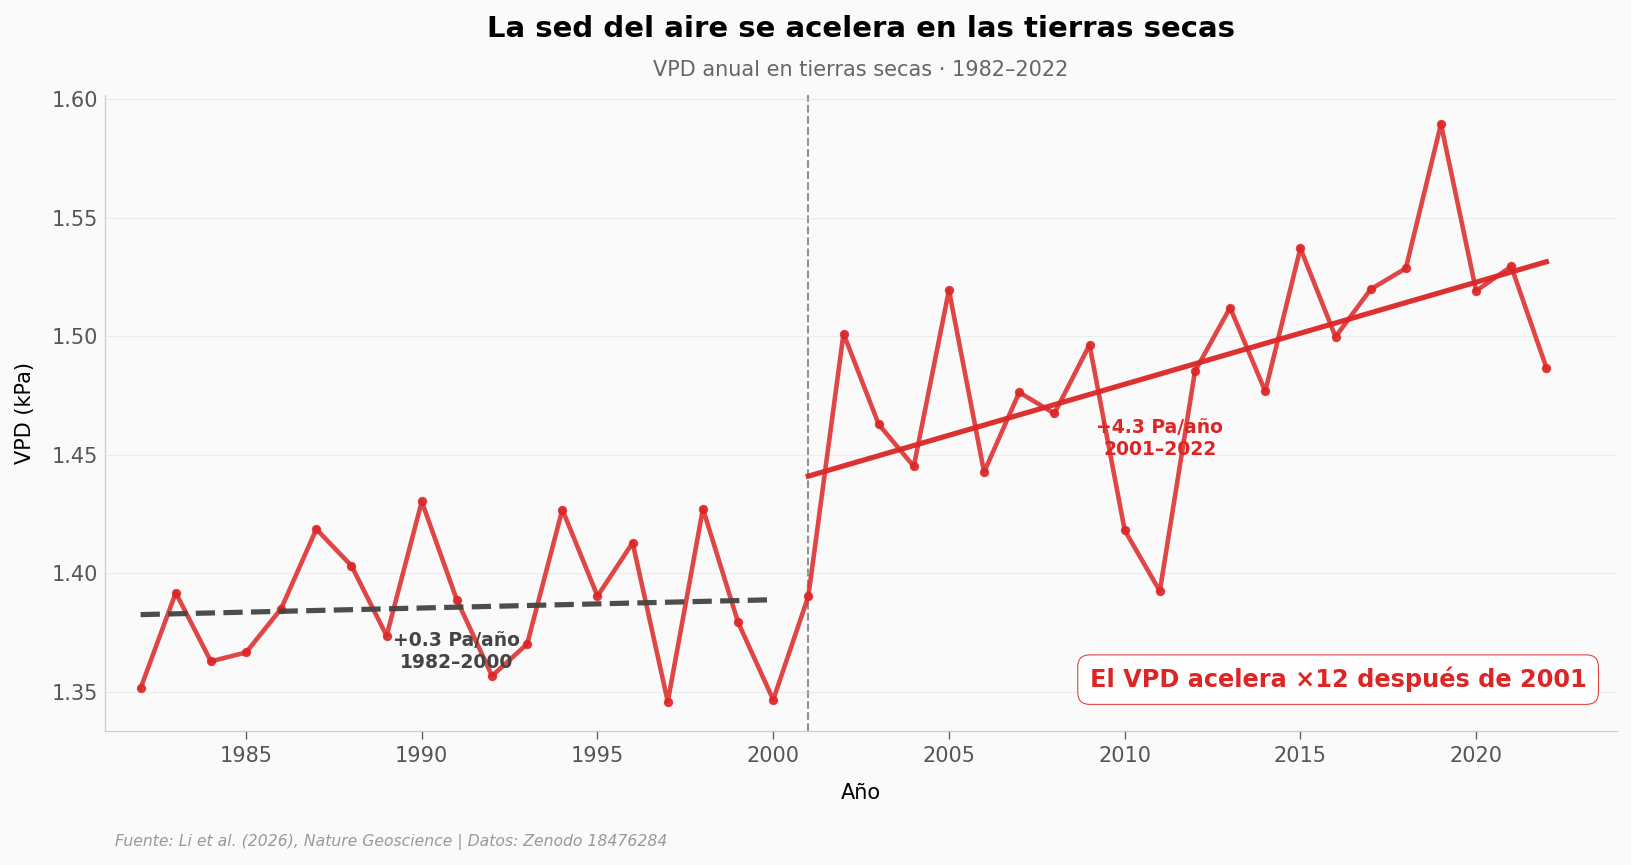


VPD tierras secas:
  Slope 1982–2000: +0.35 Pa/año por año (p=0.775) — NO significativa (planicie)
  Slope 2001–2022: +4.31 Pa/año por año (p=0.005) — significativa
  Factor de aceleración: ×12.3 (el slope pre es plano estadísticamente; el factor exacto hereda esa incertidumbre)


In [3]:
# VPD drylands con cambio de tendencia
slope_vpd_pre,  p_vpd_pre  = slope_period(serie, 'vpd_drylands_kPa', 1982, 2000)
slope_vpd_post, p_vpd_post = slope_period(serie, 'vpd_drylands_kPa', 2001, 2022)

fig, ax = plt.subplots(figsize=(13, 5.5))

# Serie VPD drylands
ax.plot(serie['anio'], serie['vpd_drylands_kPa'],
        color=COLOR_VPD, linewidth=2.2, marker='o', markersize=3.5, alpha=0.85)

# Líneas de tendencia visibles para cada período
def draw_trendline(ax, df, col, t0, t1, color, ls='-'):
    sub = df[(df['anio'] >= t0) & (df['anio'] <= t1)]
    res = stats.linregress(sub['anio'], sub[col])
    yhat = res.intercept + res.slope * sub['anio']
    ax.plot(sub['anio'], yhat, color=color, linewidth=2.5, linestyle=ls, alpha=0.95, zorder=4)
    return res

draw_trendline(ax, serie, 'vpd_drylands_kPa', 1982, 2000, '#444444', ls='--')
draw_trendline(ax, serie, 'vpd_drylands_kPa', 2001, 2022, COLOR_VPD, ls='-')

# Línea vertical en quiebre
ax.axvline(x=ANIO_QUIEBRE, color='#666666', linewidth=1.0, linestyle='--', alpha=0.7, zorder=1)

# Anotaciones de aceleración
ax.annotate(f'+{slope_vpd_pre*1000:.1f} Pa/año\n1982–2000',
            xy=(1991, 1.36), fontsize=9, color='#444444', ha='center', fontweight='bold')
ax.annotate(f'+{slope_vpd_post*1000:.1f} Pa/año\n2001–2022',
            xy=(2011, 1.45), fontsize=9, color=COLOR_VPD, ha='center', fontweight='bold')

# Factor de aceleración como inline note
factor = slope_vpd_post / slope_vpd_pre
ax.text(0.98, 0.06, f'El VPD acelera ×{factor:.0f} después de 2001',
        transform=ax.transAxes, fontsize=11.5, color=COLOR_VPD,
        fontweight='bold', ha='right', va='bottom',
        bbox=dict(boxstyle='round,pad=0.5', facecolor='white',
                  edgecolor=COLOR_VPD, alpha=0.9))

ax.set_title('La sed del aire se acelera en las tierras secas',
             fontsize=14, fontweight='bold', pad=28)
ax.text(0.5, 1.03, 'VPD anual en tierras secas · 1982–2022',
        transform=ax.transAxes, fontsize=10, color='#666666', ha='center')
ax.set_xlabel('Año', fontsize=10)
ax.set_ylabel('VPD (kPa)', fontsize=10)
ax.set_xlim(1981, 2024)

fig.text(0.13, -0.03, FUENTE, fontsize=7.5, color='#999999', style='italic')
plt.savefig('figuras/02_vpd_drylands_aceleracion.png', dpi=200, bbox_inches='tight')
plt.show()

print(f"\nVPD tierras secas:")
print(f"  Slope 1982–2000: +{slope_vpd_pre*1000:.2f} Pa/año por año (p={p_vpd_pre:.3f}) — NO significativa (planicie)")
print(f"  Slope 2001–2022: +{slope_vpd_post*1000:.2f} Pa/año por año (p={p_vpd_post:.3f}) — significativa")
print(f"  Factor de aceleración: ×{factor:.1f} (el slope pre es plano estadísticamente; el factor exacto hereda esa incertidumbre)")

## Y los modelos climáticos, ¿lo ven?

Hay dos familias de modelos que tratan de simular el GPP:

- **DGVMs** (*Dynamic Global Vegetation Models*): se enfocan en la vegetación, alimentados con clima observado.
- **ESMs** (*Earth System Models*): el sistema completo — atmósfera, océano, hielo, vegetación — los que usa el IPCC para proyectar el clima.

La pregunta es si reproducen el frenado en tierras secas. Comparemos el cambio de tendencia entre 1982–2000 y 2001–2022, bin por bin de aridez.

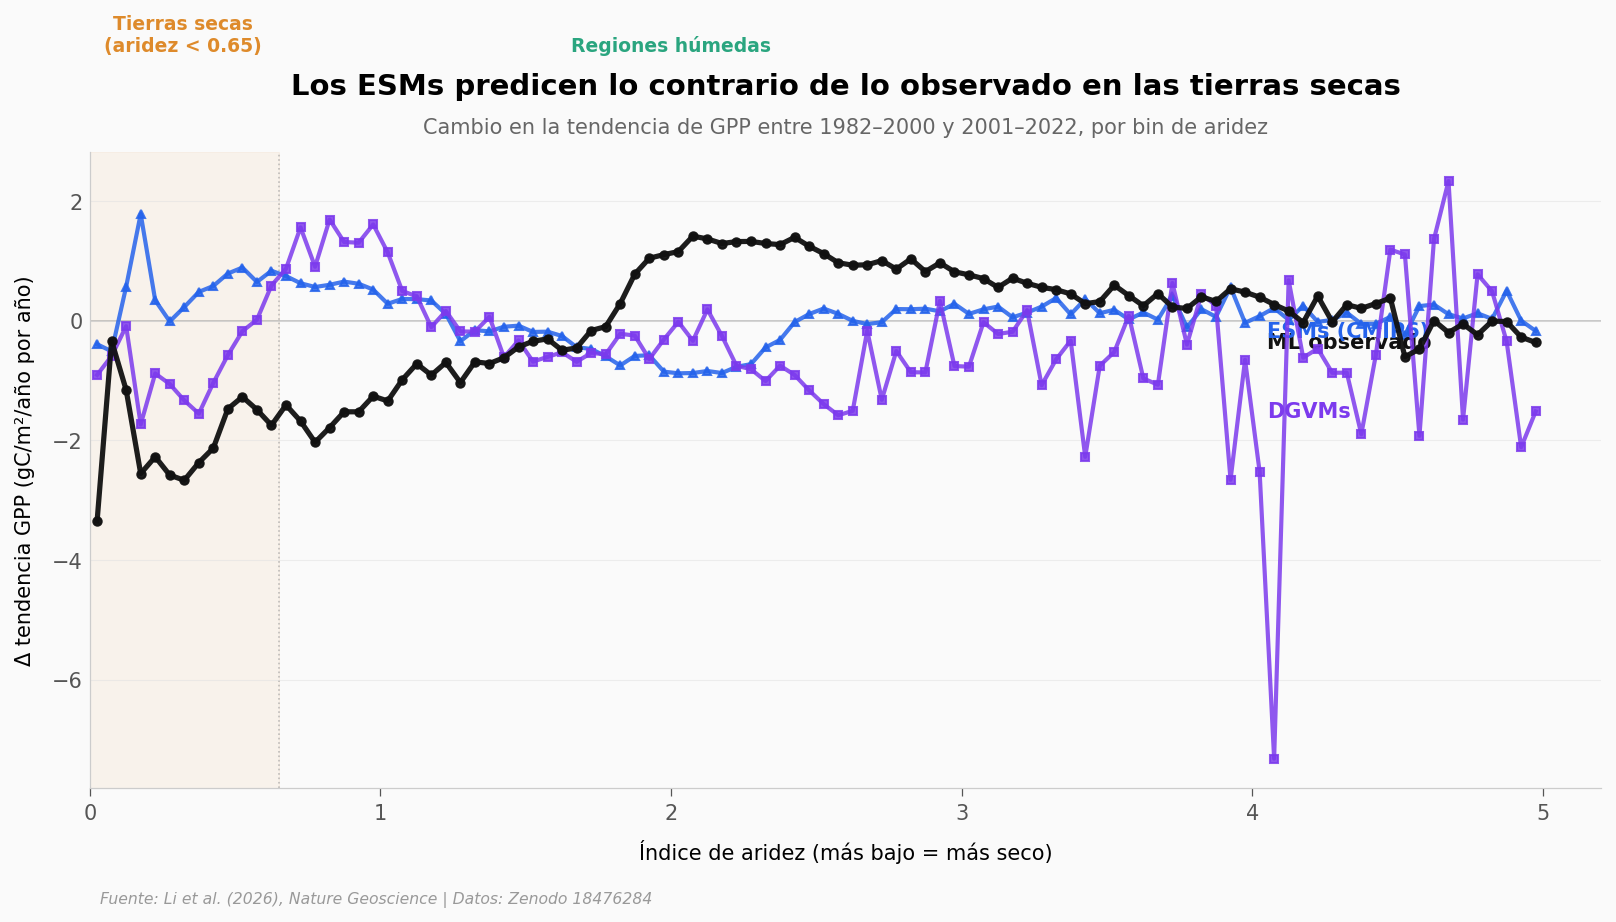


Cambio promedio de tendencia en zona dryland (aridez < 0.65):
  ML observado:  -1.95 gC/m²/año por año
  DGVMs:         -0.72 gC/m²/año por año (subestima la magnitud)
  ESMs (CMIP6):  +0.48 gC/m²/año por año (signo OPUESTO al observado)


In [4]:
# Calcular delta_slope (post - pre) para cada fuente, bin a bin
obs_dgvm['delta_ml']   = obs_dgvm['ml_obs_2001_2022'] - obs_dgvm['ml_obs_1982_2000']
obs_dgvm['delta_dgvm'] = obs_dgvm['dgvm_2001_2022']   - obs_dgvm['dgvm_1982_2000']
obs_esm['delta_esm']   = obs_esm['esm_2001_2022']     - obs_esm['esm_1982_2000']

# Asumimos misma rejilla de aridez
ai = obs_dgvm['indice_aridez']

fig, ax = plt.subplots(figsize=(13, 5.5))

ax.axhline(y=0, color='#999999', linewidth=0.8, linestyle='-', alpha=0.6, zorder=1)
ax.axvline(x=0.65, color='#999999', linewidth=0.8, linestyle=':', alpha=0.6, zorder=1)

# Sombra zona drylands
ax.axvspan(0, 0.65, alpha=0.06, color=COLOR_DRYLANDS, zorder=0)
ax.text(0.32, 4.5, 'Tierras secas\n(aridez < 0.65)',
        fontsize=9, color=COLOR_DRYLANDS, ha='center', fontweight='bold', alpha=0.85)
ax.text(2.0, 4.5, 'Regiones húmedas',
        fontsize=9, color=COLOR_HUMID, ha='center', fontweight='bold', alpha=0.85)

ax.plot(ai, obs_dgvm['delta_ml'],   color='#111111',     linewidth=2.5, marker='o', markersize=4, alpha=0.95, zorder=5)
ax.plot(ai, obs_dgvm['delta_dgvm'], color=COLOR_DGVM,    linewidth=2.0, marker='s', markersize=4, alpha=0.85, zorder=4)
ax.plot(ai, obs_esm['delta_esm'],   color=COLOR_ESM,     linewidth=2.0, marker='^', markersize=4, alpha=0.85, zorder=3)

# Etiquetas inline
ax.text(4.05, obs_dgvm['delta_ml'].iloc[-1],   'ML observado',          fontsize=10, color='#111111',  fontweight='bold', va='center')
ax.text(4.05, obs_dgvm['delta_dgvm'].iloc[-1], 'DGVMs',                 fontsize=10, color=COLOR_DGVM, fontweight='bold', va='center')
ax.text(4.05, obs_esm['delta_esm'].iloc[-1],   'ESMs (CMIP6)',          fontsize=10, color=COLOR_ESM,  fontweight='bold', va='center')

ax.set_title('Los ESMs predicen lo contrario de lo observado en las tierras secas',
             fontsize=14, fontweight='bold', pad=28)
ax.text(0.5, 1.03, 'Cambio en la tendencia de GPP entre 1982–2000 y 2001–2022, por bin de aridez',
        transform=ax.transAxes, fontsize=10, color='#666666', ha='center')
ax.set_xlabel('Índice de aridez (más bajo = más seco)', fontsize=10)
ax.set_ylabel('Δ tendencia GPP (gC/m²/año por año)', fontsize=10)
ax.set_xlim(0, 5.2)

fig.text(0.13, -0.03, FUENTE, fontsize=7.5, color='#999999', style='italic')
plt.savefig('figuras/03_modelos_vs_observacion.png', dpi=200, bbox_inches='tight')
plt.show()

# Cuantificar en zona dryland (aridez < 0.65)
mask_dry = ai < 0.65
mean_ml_dry   = obs_dgvm.loc[mask_dry, 'delta_ml'].mean()
mean_dgvm_dry = obs_dgvm.loc[mask_dry, 'delta_dgvm'].mean()
mean_esm_dry  = obs_esm.loc[mask_dry,  'delta_esm'].mean()
print(f"\nCambio promedio de tendencia en zona dryland (aridez < 0.65):")
print(f"  ML observado:  {mean_ml_dry:+.2f} gC/m²/año por año")
print(f"  DGVMs:         {mean_dgvm_dry:+.2f} gC/m²/año por año (subestima la magnitud)")
print(f"  ESMs (CMIP6):  {mean_esm_dry:+.2f} gC/m²/año por año (signo OPUESTO al observado)")

## ¿Qué tan extremo es el frenado en las tierras secas?

Mirar las tierras secas como un solo bloque puede engañar. Una forma de ver el efecto es preguntar: si tomamos los **cambios de tendencia bin por bin de aridez** (un valor por cada franja del planeta), ¿dónde caen las tierras secas dentro de la distribución global?

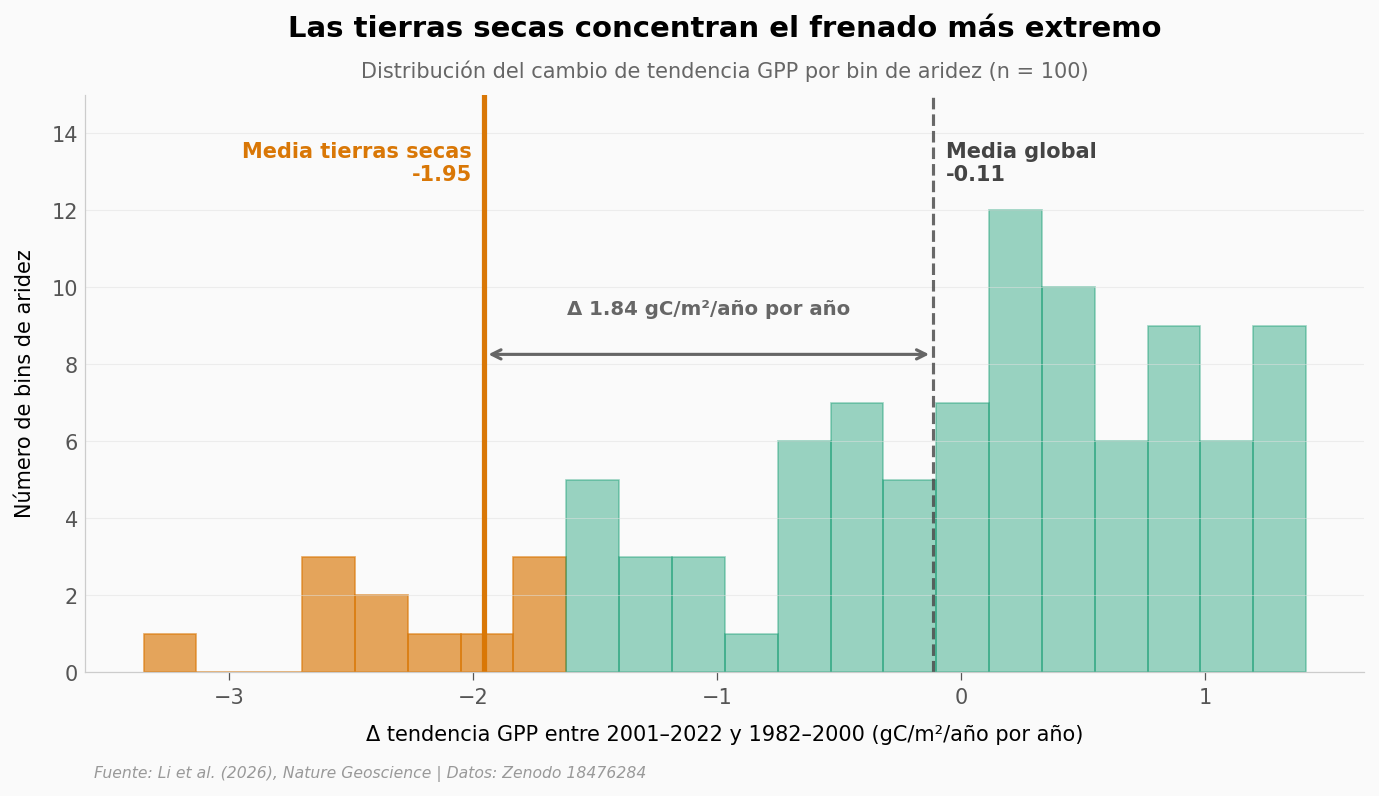


Delta-slope global (n=100 bins):
  Media:   -0.11 gC/m²/año por año
  Mediana: +0.20
  Std:     1.09

La media de tierras secas (-1.95) cae 1.84 gC/m²/año por debajo de la media global (-0.11).
(Los bins de aridez son franjas espaciales, no réplicas independientes — la SD de la distribución es descriptiva, no inferencial.)


In [5]:
# Histograma del Δslope global, con la zona drylands marcada
delta_global = obs_dgvm['delta_ml'].values
mean_global = delta_global.mean()
delta_dry_mean = mean_ml_dry  # ya calculado arriba

fig, ax = plt.subplots(figsize=(11, 5))
n, bins, patches = ax.hist(delta_global, bins=22, color=COLOR_HUMID, alpha=0.4,
                           edgecolor=COLOR_HUMID, linewidth=0.8)

# Recolorear los bins que caen en zona dryland (Δslope más negativo)
for patch, b_left in zip(patches, bins[:-1]):
    if b_left < delta_dry_mean + 0.3:  # parte negativa donde están los drylands
        patch.set_facecolor(COLOR_DRYLANDS)
        patch.set_alpha(0.65)
        patch.set_edgecolor(COLOR_DRYLANDS)

y_max = n.max() * 1.25
ax.set_ylim(0, y_max)

# Líneas verticales: media global vs media drylands
ax.axvline(x=mean_global,    color='#444444',      linewidth=1.5, linestyle='--', alpha=0.8)
ax.axvline(x=delta_dry_mean, color=COLOR_DRYLANDS, linewidth=2.5)

# Flecha entre las dos
ax.annotate('', xy=(delta_dry_mean, y_max*0.55), xytext=(mean_global, y_max*0.55),
            arrowprops=dict(arrowstyle='<->', color='#666666', lw=1.5))
ax.text((mean_global + delta_dry_mean)/2, y_max*0.62,
        f'Δ {abs(mean_global - delta_dry_mean):.2f} gC/m²/año por año',
        fontsize=9.5, color='#666666', ha='center', fontweight='bold')

# Anotaciones
ax.text(mean_global + 0.05, y_max*0.92, f'Media global\n{mean_global:+.2f}',
        fontsize=10, color='#444444', fontweight='bold', va='top')
ax.text(delta_dry_mean - 0.05, y_max*0.92, f'Media tierras secas\n{delta_dry_mean:+.2f}',
        fontsize=10, color=COLOR_DRYLANDS, fontweight='bold', va='top', ha='right')

ax.set_title('Las tierras secas concentran el frenado más extremo',
             fontsize=14, fontweight='bold', pad=28)
ax.text(0.5, 1.03, 'Distribución del cambio de tendencia GPP por bin de aridez (n = 100)',
        transform=ax.transAxes, fontsize=10, color='#666666', ha='center')
ax.set_xlabel('Δ tendencia GPP entre 2001–2022 y 1982–2000 (gC/m²/año por año)', fontsize=10)
ax.set_ylabel('Número de bins de aridez', fontsize=10)

fig.text(0.13, -0.03, FUENTE, fontsize=7.5, color='#999999', style='italic')
plt.savefig('figuras/04_histograma_delta_slope.png', dpi=200, bbox_inches='tight')
plt.show()

print(f"\nDelta-slope global (n={len(delta_global)} bins):")
print(f"  Media:   {mean_global:+.2f} gC/m²/año por año")
print(f"  Mediana: {np.median(delta_global):+.2f}")
print(f"  Std:     {delta_global.std(ddof=1):.2f}")
print(f"\nLa media de tierras secas ({delta_dry_mean:+.2f}) cae {abs(delta_dry_mean - mean_global):.2f} gC/m²/año por debajo de la media global ({mean_global:+.2f}).")
print("(Los bins de aridez son franjas espaciales, no réplicas independientes — la SD de la distribución es descriptiva, no inferencial.)")

### Lo que los datos soportan

| Afirmación | ¿Soportada? | Detalle |
|------------|-------------|---------|
| El GPP de las tierras secas se frena después de 2001 | ✅ | Slope cae de +2.73 a +0.77 gC/m²/año (−71.7%); el slope post-2001 deja de ser significativo (p=0.21). |
| Las regiones húmedas mantienen su ritmo de absorción | ✅ | Slope solo cae de +2.85 a +2.49 (−12.6%); sigue altamente significativo (p=4×10⁻⁷). |
| El VPD acelera ×12 en tierras secas tras 2001 | ✅ | Slope VPD pasa de +0.35 a +4.31 Pa/año por año. La asociación con el frenado del GPP la propone el paper, no es causalidad demostrada. |
| Los ESMs no capturan el frenado | ✅ | Δ-slope ML = −1.95; Δ-slope ESMs = +0.48 (signo opuesto). DGVMs sí ven el frenado pero subestiman la magnitud (−0.72 vs −1.95). |
| El frenado es ~5.7× más fuerte en drylands que en humid | ✅ | (1 − 0.283) / (1 − 0.874) = 5.7; coincide con el 5.7× que reporta el paper. |

> **Limitaciones:**
> - Estudio **observacional** — la asociación VPD ↔ frenado del GPP no demuestra causalidad. Los autores usan "atribuido principalmente a", no "causado por".
> - El GPP "observado" es un producto de *machine learning* a partir de torres FLUXNET; tiene incertidumbre que no entra en estos archivos resumidos.
> - Las series anuales que usamos son el promedio del *ensemble* (24 estimados de GPP) — no vemos la dispersión entre miembros.
> - Los bins por aridez (n=100) muestrean franjas climáticas, no son réplicas independientes.

## Ahora tú

Tres preguntas para abrir el dataset por tu cuenta:

1. **¿Y la temperatura?** El paper se enfoca en VPD, pero los datos también traen `ta_drylands_C`. ¿La temperatura en tierras secas también acelera tras 2001? ¿Se mueve sincronizada con el VPD?
   *Pista:* repite el bloque `slope_period` con la columna `ta_drylands_C`.

2. **¿Las regiones húmedas también aceleran VPD pero importa menos?** Compara `vpd_humid_kPa` pre/post 2001. ¿Qué tan grande es el cambio comparado con drylands?

3. **¿Qué bins de aridez son los más extremos?** En `obs_dgvm` el `delta_ml` mide el frenado por bin. ¿Cuál es el bin con la mayor caída? ¿Coincide con el rango de drylands o aparece algo inesperado?

In [6]:
# --- EXPERIMENTA AQUÍ ---
# Pregunta 3: los bins más extremos

ranking = obs_dgvm[['indice_aridez', 'delta_ml']].sort_values('delta_ml').head(10)
print("Los 10 bins con mayor frenado (Δslope más negativo):")
print(ranking.to_string(index=False))

# Comparación con humid
delta_ml_humid = obs_dgvm.loc[obs_dgvm['indice_aridez'] >= 0.65, 'delta_ml'].mean()
print(f"\nMedia Δslope en humid (aridez ≥ 0.65): {delta_ml_humid:+.2f}")
print(f"Media Δslope en drylands (aridez < 0.65): {mean_ml_dry:+.2f}")
# Las regiones húmedas no se frenan en promedio (+0.16); las drylands sí (-1.95).
# Un cociente directo no es interpretable porque los signos son opuestos.
print(f"Diferencia absoluta: drylands {abs(mean_ml_dry - delta_ml_humid):.2f} gC/m²/año por debajo de humid")
print(f"En la serie temporal el frenado relativo es 5.7× mayor en drylands (ver tabla de verificación)")

Los 10 bins con mayor frenado (Δslope más negativo):
 indice_aridez  delta_ml
         0.025 -3.349576
         0.325 -2.666460
         0.275 -2.580760
         0.175 -2.554739
         0.375 -2.371628
         0.225 -2.274115
         0.425 -2.128188
         0.775 -2.032255
         0.825 -1.786593
         0.625 -1.748188

Media Δslope en humid (aridez ≥ 0.65): +0.16
Media Δslope en drylands (aridez < 0.65): -1.95
Diferencia absoluta: drylands 2.11 gC/m²/año por debajo de humid
En la serie temporal el frenado relativo es 5.7× mayor en drylands (ver tabla de verificación)


---

## Fuentes

**Paper**: [Dryland dominance in the slowdown of global vegetation carbon uptake](https://doi.org/10.1038/s41561-026-01957-8)  
*Nature Geoscience, 2026-04-01*

**Datos**: [Datasets and code for dryland dominance in the slowdown of global vegetation carbon uptake](https://doi.org/10.5281/zenodo.18476284)

*22 afirmaciones verificadas contra estas fuentes*

**Reproducibilidad:**
- Datos públicos: [Zenodo 18476284](https://doi.org/10.5281/zenodo.18476284) (CC-BY 4.0)
- Repo: [Ciencia-a-Mordiscos/lab](https://github.com/Ciencia-a-Mordiscos/lab) — notebook `papers/2026-04-01-tierras-secas-frenan-co2-vegetal/`
- Licencia notebook: CC-BY 4.0